# AgileTaskHeron – Large Scale Example

**200 Persons × 50 Tasks** Realistic Enterprise Demo

This notebook shows a large-scale example suitable for real companies or research labs.

- Persons: 2000  
- Tasks: 50  
- Skills: 25  

Total edges: ~3,500

### Performance

Tested on a large-scale example (2000 persons, 50 tasks, ~3,500 edges):

- **2000 persons** scale → **1.91 seconds** (Wall time)
- Generated **30 task bundles** with priority ranking and person contribution scores

Even at enterprise scale, AgileTaskHeron delivers results in **under 2 seconds** on GPU, making it practical for real-time or near-real-time Agile decision making.

### This demo was done on AWS g4dn.xlarge instance 

In [1]:
import cudf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="cugraph")

np.random.seed(42)

# Create nodes
persons = [f"Person{i:03d}" for i in range(1, 2001)]
tasks   = [f"Task{i:03d}" for i in range(1, 51)]
skills  = [f"Skill{i:03d}" for i in range(1, 26)]

edges_list = []


# Core Skills 
core_skills = skills[:12]

# 1. Person → Has_Skill
for p in persons:
    num = np.random.randint(6, 14)
    selected = np.random.choice(skills, num, replace=False)
    for s in selected:
        edges_list.append([p, s, 'Has_Skill', round(np.random.uniform(0.55, 1.0), 2)])

# 2. Task → Requires_Skill 
for t in tasks:
    # Core skills are required for every task
    num_core = np.random.randint(8, 12)
    core_selected = np.random.choice(core_skills, num_core, replace=False)
    
    # 추가 스킬 (일반 스킬)
    num_extra = np.random.randint(4, 9)
    extra_skills = [s for s in skills if s not in core_skills]
    extra_selected = np.random.choice(extra_skills, num_extra, replace=False)
    
    required = list(core_selected) + list(extra_selected)
    
    for s in required:
        edges_list.append([t, s, 'Requires_Skill', round(np.random.uniform(0.7, 1.0), 2)])

# 3. Person → Completed
for p in persons:
    num = np.random.randint(12, 40)
    selected = np.random.choice(tasks, num, replace=False)
    for t in selected:
        edges_list.append([p, t, 'Completed', round(np.random.uniform(0.3, 0.95), 2)])

# 4. Person → Assigned_To
for p in persons:
    num = np.random.randint(2, 7)
    selected = np.random.choice(tasks, num, replace=False)
    for t in selected:
        edges_list.append([p, t, 'Assigned_To', round(np.random.uniform(0.75, 1.0), 2)])

# 5. Task → Depends_On
for t in tasks:
    num = np.random.randint(0, 7)
    if num > 0:
        possible = [tt for tt in tasks if tt != t]
        selected = np.random.choice(possible, num, replace=False)
        for d in selected:
            edges_list.append([t, d, 'Depends_On', round(np.random.uniform(0.4, 0.85), 2)])

# Create edges
pdf = pd.DataFrame(edges_list, columns=['src', 'dst', 'edge_type', 'weight'])
edges = cudf.from_pandas(pdf)

print(f"✅ Total Edges: {len(edges):,}")
print(f"   Persons: {len(persons):,} | Tasks: {len(tasks):,} | Skills: {len(skills):,}")
print("\nEdge Type Distribution:")
print(edges['edge_type'].value_counts().to_pandas())

✅ Total Edges: 78,935
   Persons: 2,000 | Tasks: 50 | Skills: 25

Edge Type Distribution:
edge_type
Completed         51107
Has_Skill         18913
Assigned_To        7986
Requires_Skill      784
Depends_On          145
Name: count, dtype: int64


### Run Analysis

In [2]:
%%time 
from agile_task_bundle import analyze_task_bundle

result = analyze_task_bundle(edges)
print(f"Analysis completed! {len(result['priority_bundles'])} task bundles generated.")

Analysis completed! 30 task bundles generated.
CPU times: user 1.66 s, sys: 227 ms, total: 1.89 s
Wall time: 1.91 s


In [3]:
result

{'priority_bundles': [{'priority': 1,
   'task': 'Task034',
   'score': 0.0066,
   'required_skills': ['Skill023',
    'Skill017',
    'Skill025',
    'Skill022',
    'Skill008',
    'Skill011',
    'Skill021',
    'Skill020'],
   'available_people': ['Person1817',
    'Person1993',
    'Person1832',
    'Person1969',
    'Person1443',
    'Person081',
    'Person1525',
    'Person1258',
    'Person757',
    'Person628',
    'Person1107',
    'Person495',
    'Person1150',
    'Person1990',
    'Person1590',
    'Person053',
    'Person281',
    'Person1400',
    'Person1662',
    'Person1520',
    'Person668',
    'Person1259',
    'Person1218',
    'Person801',
    'Person1604',
    'Person1680',
    'Person366',
    'Person1582',
    'Person221',
    'Person1486',
    'Person1037',
    'Person280',
    'Person840',
    'Person1334',
    'Person579',
    'Person1226',
    'Person1978',
    'Person468',
    'Person1633',
    'Person1946',
    'Person1489',
    'Person477',
    'Person

### Business-Friendly Visualization

/tmp/ipykernel_5139/3634166350.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=tasks, palette="Blues_d")


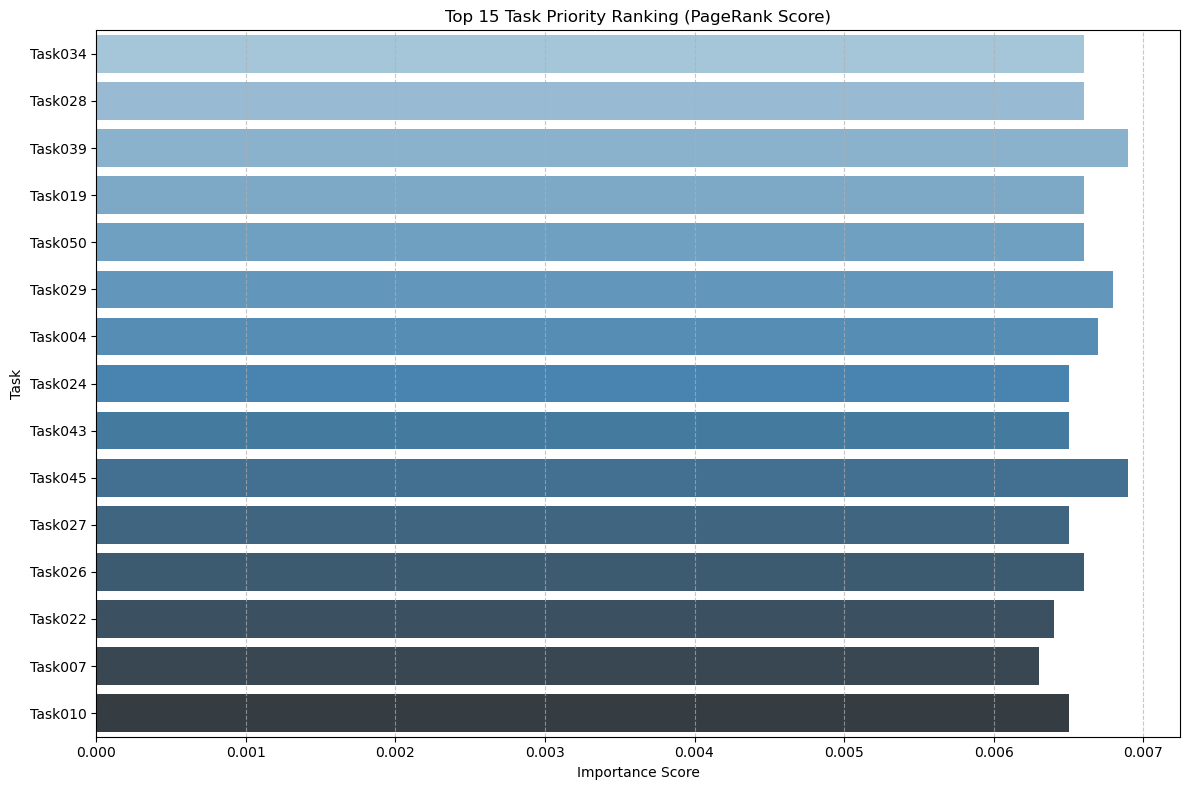


=== Top 10 Task Force Bundles Summary ===

 1 | Task034    | Score: 0.0066 | Skills: 8 | People: 326
 2 | Task028    | Score: 0.0066 | Skills: 0 | People: 7
 3 | Task039    | Score: 0.0069 | Skills: 0 | People: 9
 4 | Task019    | Score: 0.0066 | Skills: 0 | People: 16
 5 | Task050    | Score: 0.0066 | Skills: 0 | People: 6
 6 | Task029    | Score: 0.0068 | Skills: 0 | People: 9
 7 | Task004    | Score: 0.0067 | Skills: 0 | People: 9
 8 | Task024    | Score: 0.0065 | Skills: 0 | People: 6
 9 | Task043    | Score: 0.0065 | Skills: 0 | People: 6
10 | Task045    | Score: 0.0069 | Skills: 0 | People: 5


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 15 Task Priority Bar Chart
top_bundles = result["priority_bundles"][:15]

tasks = [b['task'] for b in top_bundles]
scores = [b['score'] for b in top_bundles]

plt.figure(figsize=(12, 8))
sns.barplot(x=scores, y=tasks, palette="Blues_d")
plt.title("Top 15 Task Priority Ranking (PageRank Score)")
plt.xlabel("Importance Score")
plt.ylabel("Task")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Bundle Summary Table
print("\n=== Top 10 Task Force Bundles Summary ===\n")
for bundle in top_bundles[:10]:
    print(f"{bundle['priority']:2d} | {bundle['task']:<10} | Score: {bundle['score']:.4f} | "
          f"Skills: {len(bundle['required_skills'])} | People: {len(bundle['available_people'])}")

### Plot Person Contribution (PageRank Score) per Bundle

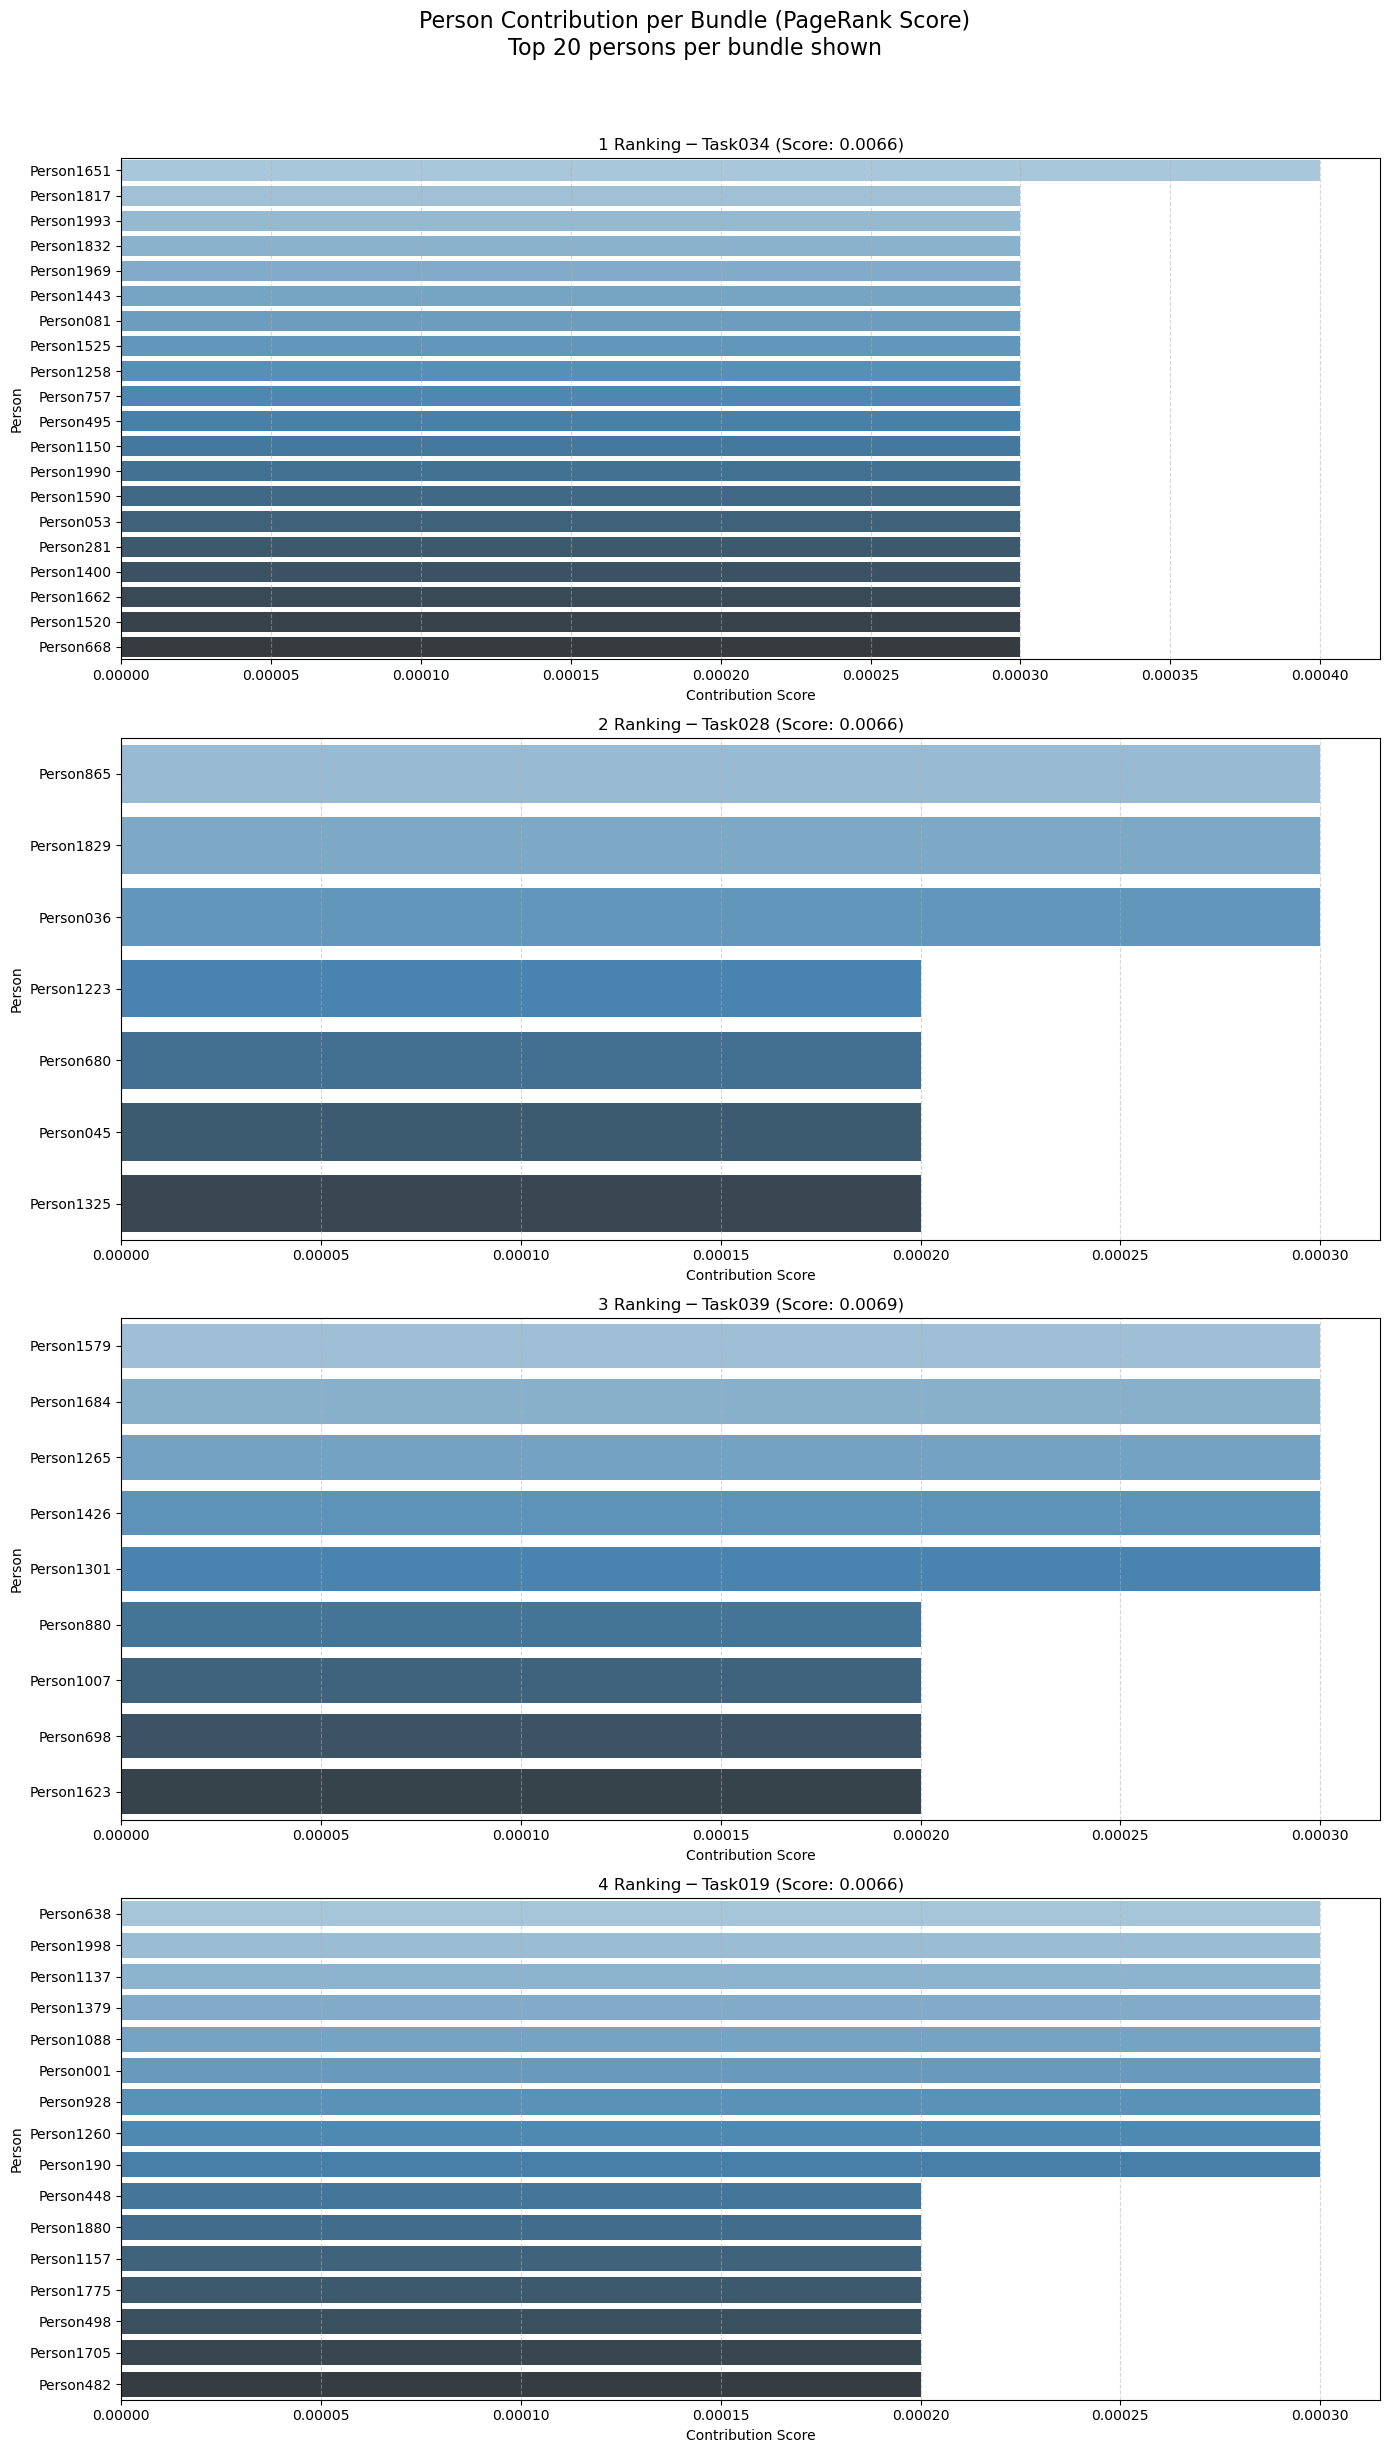

In [5]:

top_bundles = result["priority_bundles"][:4]

fig, axes = plt.subplots(len(top_bundles), 1, figsize=(14, 6 * len(top_bundles)))
fig.suptitle("Person Contribution per Bundle (PageRank Score)\nTop 20 persons per bundle shown", 
             fontsize=16, y=1.02)

for i, bundle in enumerate(top_bundles):
    people = bundle['person_details']
    
    people_sorted = sorted(people, key=lambda x: x['contribution'], reverse=True)[:20]
    
    names = [p['person'] for p in people_sorted]
    contrib = [p['contribution'] for p in people_sorted]
    
    # FutureWarning 
    sns.barplot(x=contrib, y=names, hue=names, palette="Blues_d", legend=False, ax=axes[i])
    
    axes[i].set_title(f"{bundle['priority']} Ranking ─ {bundle['task']} (Score: {bundle['score']:.4f})")
    axes[i].set_xlabel("Contribution Score")
    axes[i].set_ylabel("Person")
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)
    
    axes[i].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()